In [3]:
!gdown 1xmZEntbsMMEYuCapJfYw72GihKgiGA97
!gdown 1oYniud9VFUP2nRnxfKl9eU0yQQsk2mR9
!gdown 1ToSqzT5XCYrUlKB-3skfv1chBHti662N

Downloading...
From: https://drive.google.com/uc?id=1xmZEntbsMMEYuCapJfYw72GihKgiGA97
To: /home/clown2/Desktop/Work/Courses/EAIS/LS_BRT_v1_w1.25.npy
100%|████████████████████████████████████████| 531k/531k [00:00<00:00, 8.70MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1oYniud9VFUP2nRnxfKl9eU0yQQsk2mR9
From (redirected): https://drive.google.com/uc?id=1oYniud9VFUP2nRnxfKl9eU0yQQsk2mR9&confirm=t&uuid=9daf6f5d-9c12-45de-a813-988ebc5ba1fd
To: /home/clown2/Desktop/Work/Courses/EAIS/best_pretrain_joint_0_10.pt
100%|████████████████████████████████████████| 324M/324M [00:06<00:00, 52.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1ToSqzT5XCYrUlKB-3skfv1chBHti662N
To: /home/clown2/Desktop/Work/Courses/EAIS/best_classifier_0_01.pt
100%|██████████████████████████████████████| 40.7k/40.7k [00:00<00:00, 4.55MB/s]


In [1]:
!python eais_hw2/safety_rl/latent_dubins_avoid.py

['/home/clown2/Desktop/Work/Courses/EAIS/eais_hw2/safety_rl', '/home/clown2/anaconda3/envs/safety_rl/lib/python37.zip', '/home/clown2/anaconda3/envs/safety_rl/lib/python3.7', '/home/clown2/anaconda3/envs/safety_rl/lib/python3.7/lib-dynload', '/home/clown2/anaconda3/envs/safety_rl/lib/python3.7/site-packages', '/home/clown2/Desktop/Work/Courses/EAIS/eais_hw2', '/home/clown2/Desktop/Work/Courses/EAIS/eais_hw2/dreamerv3-torch']
dict_keys(['logdir', 'traindir', 'evaldir', 'offline_traindir', 'offline_evaldir', 'seed', 'deterministic_run', 'steps', 'parallel', 'eval_every', 'eval_episode_num', 'log_every', 'reset_every', 'device', 'compile', 'precision', 'debug', 'video_pred_log', 'num_exp_trajs', 'pretrain_steps', 'task', 'size', 'envs', 'action_repeat', 'time_limit', 'grayscale', 'prefill', 'reward_EMA', 'dyn_hidden', 'dyn_deter', 'dyn_stoch', 'dyn_discrete', 'dyn_rec_depth', 'dyn_mean_act', 'dyn_std_act', 'dyn_min_std', 'grad_heads', 'units', 'act', 'norm', 'encoder', 'decoder', 'actor',

1. Get RBG + theta
2. Encode the latent
3. run latent through value function 
4. if value < epsilon, filter

In [ ]:
import pickle 

with open('wm_demos128.pkl', 'rb') as f:
    data = pickle.load(f)

print(type(data))

data[0]['obs']['image'][0].shape

sample_img = data[0]['obs']['image'][0]
print(sample_img.shape)

import matplotlib.pyplot as plt

plt.figure()

for im in data[0]['obs']['image']:
    plt.figure()
    plt.imshow(im)

<class 'list'>


In [ ]:
import os
import sys
parent_dir = os.getcwd()
sys.path.append(parent_dir)
dreamer_dir = os.path.abspath(os.path.join(os.getcwd(), 'eais_hw2/dreamerv3-torch'))
sys.path.append(dreamer_dir)
print(sys.path)

import models
import torch

safeV = torch.load("logs/experiments/car-DDQN/latent-toEnd/model/Q-250000.pth")


['/home/clown2/Desktop/Work/Courses/EAIS', '/home/clown2/anaconda3/envs/safety_rl/lib/python37.zip', '/home/clown2/anaconda3/envs/safety_rl/lib/python3.7', '/home/clown2/anaconda3/envs/safety_rl/lib/python3.7/lib-dynload', '', '/home/clown2/anaconda3/envs/safety_rl/lib/python3.7/site-packages', '/home/clown2/anaconda3/envs/safety_rl/lib/python3.7/site-packages/IPython/extensions', '/home/clown2/.ipython', '/home/clown2/Desktop/Work/Courses/EAIS', '/home/clown2/Desktop/Work/Courses/EAIS/eais_hw2/dreamerv3-torch', '/home/clown2/Desktop/Work/Courses/EAIS', '/home/clown2/Desktop/Work/Courses/EAIS/eais_hw2/dreamerv3-torch', '/home/clown2/Desktop/Work/Courses/EAIS', '/home/clown2/Desktop/Work/Courses/EAIS/eais_hw2/dreamerv3-torch']


collections.OrderedDict

In [9]:
import pickle

pkl_file = "wm_demos_cont_act128.pkl"
with open(pkl_file, 'rb') as f:
    data = pickle.load(f)
print(type(data))

<class 'list'>


In [25]:
demo1_img = data[0]['obs']['image'][0]
demo1_state = data[0]['obs']['state'][0]

In [26]:
print(demo1_img.shape)
print(demo1_state)

(128, 128, 3)
5.7501183


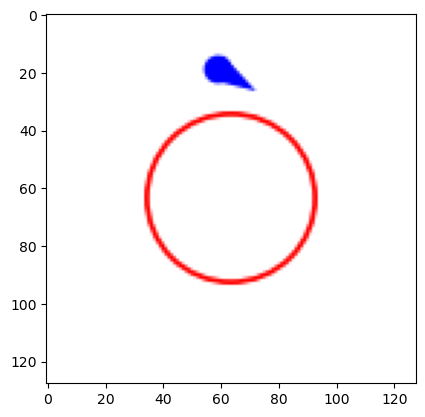

In [14]:
(data[0]['obs']['image'][0]).shape

import matplotlib.pyplot as plt

plt.figure()
plt.imshow(data[0]['obs']['image'][0])

In [21]:
import argparse
import os
import sys
import pprint

import gymnasium #as gym
import gym
import numpy as np
import torch
from torch.utils.tensorboard import SummaryWriter

parent_dir = "/home/clown2/Desktop/Work/Courses/EAIS/"
sys.path.append(parent_dir)
dreamer_dir = "/home/clown2/Desktop/Work/Courses/EAIS/eais_hw2/dreamerv3-torch"
sys.path.append(dreamer_dir)
print(sys.path)

import models
import tools
import ruamel.yaml as yaml

from PyHJ.data import Collector, VectorReplayBuffer
from PyHJ.env import DummyVectorEnv
from PyHJ.exploration import GaussianNoise
from PyHJ.trainer import offpolicy_trainer
from PyHJ.utils import TensorboardLogger
from PyHJ.utils.net.common import Net
from PyHJ.utils.net.continuous import Actor, Critic
import PyHJ.reach_rl_gym_envs as reach_rl_gym_envs

from termcolor import cprint
from datetime import datetime
import pathlib
from pathlib import Path
import collections

# note: need to include the dreamerv3 repo for this
from dreamer import make_dataset

# Remove Jupyter's arguments before creating the parser
if '--f' in sys.argv:
    # Find the index of the Jupyter argument
    f_idx = sys.argv.index('--f')
    # Remove the argument and its value
    sys.argv.pop(f_idx)
    if f_idx < len(sys.argv):
        sys.argv.pop(f_idx)
        
# Alternatively, a more comprehensive approach:
if 'ipykernel_launcher.py' in sys.argv[0]:
    # Remove all arguments that Jupyter might have added
    sys.argv = [sys.argv[0]]

def recursive_update(base, update):
    for key, value in update.items():
        if isinstance(value, dict) and key in base:
            recursive_update(base[key], value)
        else:
            base[key] = value

def get_args():
    parser = argparse.ArgumentParser()
    
    parser.add_argument("--configs", nargs="+")
    parser.add_argument("--expt_name", type=str, default=None)
    parser.add_argument("--resume_run", type=bool, default=False)
    # environment parameters
    config, remaining = parser.parse_known_args()


    if not config.resume_run:
        curr_time = datetime.now().strftime("%m%d/%H%M%S")
        config.expt_name = (
            f"{curr_time}_{config.expt_name}" if config.expt_name else curr_time
        )
    else:
        assert config.expt_name, "Need to provide experiment name to resume run."

    yml = yaml.YAML(typ="safe", pure=True)
    configs = yml.load((pathlib.Path(sys.argv[0]).parent.parent.parent.parent.parent / "/home/clown2/Desktop/Work/Courses/EAIS/PytorchReachability/HJconfig.yaml").read_text())
    name_list = ["defaults", *config.configs] if config.configs else ["defaults"]
    defaults = {}

    for name in name_list:
        recursive_update(defaults, configs[name])
    parser = argparse.ArgumentParser()
    for key, value in sorted(defaults.items(), key=lambda x: x[0]):
        arg_type = tools.args_type(value)
        parser.add_argument(f"--{key}", type=arg_type, default=arg_type(value))
    final_config = parser.parse_args(remaining)

    final_config.logdir = f"{final_config.logdir+'/lcrl'}/{config.expt_name}"

    print("---------------------")
    cprint(f"Experiment name: {config.expt_name}", "red", attrs=["bold"])
    cprint(f"Task: {final_config.task_lcrl}", "cyan", attrs=["bold"])
    cprint(f"Logging to: {final_config.logdir+'/lcrl'}", "cyan", attrs=["bold"])
    print("---------------------")
    return final_config


args=get_args()
config = args

# set up the environment spaces
image_size = config.size[0] #128
img_obs_space = gym.spaces.Box(low=0, high=255, shape=(image_size, image_size, 3), dtype=np.uint8)
obs_space = gym.spaces.Box(low=0, high=1, shape=(2,), dtype=np.float32)
high = np.array([1.1, 1.1, 2*np.pi,])
low = np.array([-1.1, -1.1, 0.,])
gt_observation_space = gym.spaces.Box(low=low, high=high, dtype=np.float32)
bool_space = gym.spaces.Box(low=False, high=True, shape=(), dtype=bool)
observation_space = gym.spaces.Dict({'obs_state': obs_space,
                                     'image': img_obs_space,
                                     'state': gt_observation_space,})
u_max = 1.25
action_space = gym.spaces.Box(low=-u_max, high=u_max, shape=(1,), dtype=np.float32)
config.num_actions = action_space.n if hasattr(action_space, "n") else action_space.shape[0]

# load WM
wm = models.WorldModel(observation_space, action_space, 0, config)
ckpt_path = '/home/clown2/Desktop/Work/Courses/EAIS/logs/dreamer_dubins/best_pretrain_joint_0_12.pt'
checkpoint = torch.load(ckpt_path)
state_dict = {k[14:]:v for k,v in checkpoint['agent_state_dict'].items() if '_wm' in k}
wm.load_state_dict(state_dict)

directory = '/home/clown2/Desktop/Work/Courses/EAIS/wm_demos_cont_act128.pkl'
train_eps = tools.load_episodes(directory, limit=config.dataset_size)
expert_eps = collections.OrderedDict()

config.batch_size = 1
config.batch_length = 5
# only need this
train_dataset = make_dataset(train_eps, config)
tools.fill_expert_dataset_dubins(config, expert_eps)
expert_dataset = make_dataset(expert_eps, config)

# NOTE: should only need 1 dataset: the offline dataset u collected from the script.
datasets = [train_dataset, expert_dataset]


env = gymnasium.make(args.task_lcrl, params = [wm, datasets, config])
assert hasattr(env, 'action_space')
args.state_shape = env.observation_space.shape or env.observation_space.n
args.action_shape = env.action_space.shape or env.action_space.n
args.max_action = env.action_space.high[0]

args.action1_shape = env.action_space.shape or env.action_space.n
args.max_action1 = env.action_space.high[0]

# seed
np.random.seed(args.seed)
torch.manual_seed(args.seed)

activation_map = {
    'ReLU': torch.nn.ReLU,
    'Tanh': torch.nn.Tanh,
    'Sigmoid': torch.nn.Sigmoid,
    'SiLU': torch.nn.SiLU
}

actor_activation = activation_map.get(args.actor_activation)
critic_activation = activation_map.get(args.critic_activation)

assert args.critic_net is not None, "Please provide critic_net!"
    
critic_net = Net(
    args.state_shape,
    args.action_shape,
    hidden_sizes=args.critic_net,
    activation=critic_activation,
    concat=True,
    device=args.device
    )

critic = Critic(critic_net, device=args.device).to(args.device)
critic_optim = torch.optim.Adam(critic.parameters(), lr=args.critic_lr)

from PyHJ.policy import avoid_DDPGPolicy_annealing as DDPGPolicy

print("DDPG under the Avoid annealed Bellman equation with no Disturbance has been loaded!")

actor1_net = Net(args.state_shape, hidden_sizes=args.control_net, activation=actor_activation, device=args.device)
actor1 = Actor(actor1_net, args.action1_shape, max_action=args.max_action1, device=args.device).to(args.device)
actor1_optim = torch.optim.Adam(actor1.parameters(), lr=args.actor_lr)

policy = DDPGPolicy(
    critic,
    critic_optim,
    tau=args.tau,
    gamma=args.gamma_lcrl,
    exploration_noise=GaussianNoise(sigma=args.exploration_noise),
    reward_normalization=args.rew_norm,
    estimation_step=args.n_step,
    action_space=env.action_space,
    actor1=actor1,
    actor1_optim=actor1_optim,
    actor_gradient_steps=args.actor_gradient_steps,
    )

# load policy
policy_path = "dreamer_l2_lessrand/lcrl/0411/142538/lcrl/dubins-wm/wm_actor_activation_ReLU_critic_activation_ReLU_game_gd_steps_1_tau_0.005_training_num_1_buffer_size_40000_c_net_512_4_a1_512_4_a2_512_4_gamma_0.95/noise_0.1_actor_lr_0.0001_critic_lr_0.001_batch_512_step_per_epoch_40000_kwargs_{}_seed_0/epoch_id_40/policy.pth"
policy.load_state_dict(torch.load(policy_path))


['/home/clown2/Desktop/Work/Courses/EAIS', '/home/clown2/anaconda3/envs/safety_rl/lib/python37.zip', '/home/clown2/anaconda3/envs/safety_rl/lib/python3.7', '/home/clown2/anaconda3/envs/safety_rl/lib/python3.7/lib-dynload', '', '/home/clown2/anaconda3/envs/safety_rl/lib/python3.7/site-packages', '/home/clown2/Desktop/Work/Courses/EAIS/PytorchReachability', '/home/clown2/anaconda3/envs/safety_rl/lib/python3.7/site-packages/IPython/extensions', '/home/clown2/.ipython', '/home/clown2/Desktop/Work/Courses/EAIS/', '/home/clown2/Desktop/Work/Courses/EAIS/eais_hw2/dreamerv3-torch', '/home/clown2/Desktop/Work/Courses/EAIS/eais_hw2/dreamerv3-torch', '/home/clown2/Desktop/Work/Courses/EAIS/', '/home/clown2/Desktop/Work/Courses/EAIS/eais_hw2/dreamerv3-torch', '/home/clown2/Desktop/Work/Courses/EAIS/', '/home/clown2/Desktop/Work/Courses/EAIS/eais_hw2/dreamerv3-torch', '/home/clown2/Desktop/Work/Courses/EAIS/', '/home/clown2/Desktop/Work/Courses/EAIS/eais_hw2/dreamerv3-torch', '/home/clown2/Desktop/

/home/clown2/anaconda3/envs/safety_rl/lib/python3.7/site-packages/gym/logger.py:30: UserWarning: WARN: Box bound precision lowered by casting to float32
  warnings.warn(colorize('%s: %s'%('WARN', msg % args), 'yellow'))


Decoder CNN shapes: {'image': (128, 128, 3)}
Decoder MLP shapes: {'obs_state': (2,)}
decoder
Optimizer model_opt has 27133189 variables.


Loading expert buffer with -1 trajectories from /home/clown2/Desktop/Work/Courses/EAIS/wm_demos_cont_act128.pkl
DDPG under the Avoid annealed Bellman equation with no Disturbance has been loaded!


<All keys matched successfully>

In [73]:
config.batch_size = 1
config.batch_length = 1
expert_dataset1 = make_dataset(expert_eps, config)
expert_dataset1

<generator object from_generator at 0x724e997c8050>

In [109]:
itraj = next(expert_dataset1)

In [110]:
itraj['image'].shape

(1, 1, 128, 128, 3)

In [111]:
idata = wm.preprocess(itraj)
idata

{'image': tensor([[[[[1., 1., 1.],
            [1., 1., 1.],
            [1., 1., 1.],
            ...,
            [1., 1., 1.],
            [1., 1., 1.],
            [1., 1., 1.]],
 
           [[1., 1., 1.],
            [1., 1., 1.],
            [1., 1., 1.],
            ...,
            [1., 1., 1.],
            [1., 1., 1.],
            [1., 1., 1.]],
 
           [[1., 1., 1.],
            [1., 1., 1.],
            [1., 1., 1.],
            ...,
            [1., 1., 1.],
            [1., 1., 1.],
            [1., 1., 1.]],
 
           ...,
 
           [[1., 1., 1.],
            [1., 1., 1.],
            [1., 1., 1.],
            ...,
            [1., 1., 1.],
            [1., 1., 1.],
            [1., 1., 1.]],
 
           [[1., 1., 1.],
            [1., 1., 1.],
            [1., 1., 1.],
            ...,
            [1., 1., 1.],
            [1., 1., 1.],
            [1., 1., 1.]],
 
           [[1., 1., 1.],
            [1., 1., 1.],
            [1., 1., 1.],
            ...

In [100]:
cnn_inp = torch.cat([idata[k] for k in wm.encoder.cnn_shapes], -1)
mlp_inp = torch.cat([idata[k] for k in wm.encoder.mlp_shapes], -1)
cnn_out = wm.encoder._cnn(cnn_inp)
mlp_out = wm.encoder._mlp(mlp_inp)
print(cnn_inp.shape)
print(cnn_out.shape)
print(mlp_inp.shape)
print(mlp_out.shape)

torch.Size([1, 1, 128, 128, 3])
torch.Size([1, 1, 8192])
torch.Size([1, 1, 2])
torch.Size([1, 1, 1024])


In [ ]:
action = torch.tensor([[[0.]]], device='cuda:0')
is_first = torch.tensor([[1.]], device='cuda:0')
latent,_ = wm.dynamics.observe(wm.encoder(idata), action, is_first)

for k, v in latent.items(): 
    latent[k] = v[:, [-1]]

feat = wm.dynamics.get_feat(latent).detach().cpu().numpy() 
feat.shape


array([[[ 6.72697163e+00,  2.09805226e+00,  6.86222672e-01,
         -3.87006474e+00, -1.26423931e+00,  8.50737453e-01,
         -5.11094427e+00,  3.10249031e-02,  1.92958987e+00,
          1.26647341e+00, -4.34918165e+00, -6.09647274e-01,
          5.96038914e+00,  3.18833852e+00, -4.09273720e+00,
          3.27621651e+00,  8.21758747e-01,  2.10001922e+00,
         -2.03162265e+00, -5.34466839e+00, -6.12022352e+00,
          4.21428967e+00,  7.18697429e-01,  6.10826433e-01,
         -1.67792630e+00,  1.59653172e-01, -7.99362183e-01,
          2.59216046e+00,  3.25459957e+00,  4.83577824e+00,
         -2.23902035e+00, -1.14490008e+00, -2.01555401e-01,
          2.02678472e-01,  3.34599009e-03,  5.95870726e-02,
          4.25268617e-03,  5.12006432e-02, -9.15905833e-02,
         -4.05010320e-02,  1.67974576e-01,  8.03210400e-03,
         -7.81698078e-02,  1.54493570e-01, -2.51813531e-02,
          1.78849772e-02,  1.78394187e-02, -1.00571476e-03,
         -2.31743172e-01,  7.63835162e-0

In [105]:
wm.heads['encoder']

KeyError: 'encoder'

In [87]:
wm.encoder.cnn_shapes
wm.encoder.mlp_shapes

{'obs_state': (2,)}

In [78]:
iembed = wm.encoder(idata)
iembed.shape

torch.Size([1, 1, 9216])

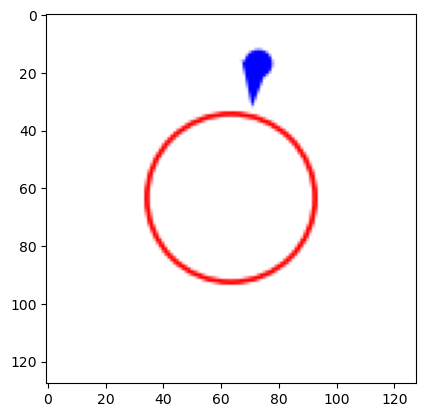

In [81]:
idata['image'].shape
plt.figure()    
plt.imshow(idata['image'][0,0].cpu().detach().numpy())

In [82]:
from PyHJ.data import Batch

def find_a(state):
    tmp_obs = np.array(state).reshape(1,-1)
    tmp_batch = Batch(obs = tmp_obs, info = Batch())
    tmp = policy(tmp_batch, model = "actor_old").act
    act = policy.map_action(tmp).cpu().detach().numpy().flatten()
    return act

def evaluate_V(state):
    tmp_obs = np.array(state).reshape(1,-1)
    tmp_batch = Batch(obs = tmp_obs, info = Batch())
    tmp = policy.critic(tmp_batch.obs, policy(tmp_batch, model="actor_old").act)
    return tmp.cpu().detach().numpy().flatten()

In [83]:
evaluate_V(iembed.cpu().detach())

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x9216 and 544x512)